In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [3]:
# Load the dataset directly using the simple relative path
df = pd.read_csv("data/indian_ecommerce_pricing_revenue_growth.csv")

In [4]:
# Print dataset dimensions to confirm successful loading
print("Dataset Shape:", df.shape)

Dataset Shape: (30600, 16)


In [5]:
# View the column names to see our features
print("\nColumns in Dataset:")
print(df.columns)


Columns in Dataset:
Index(['order_id', 'order_date', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure'],
      dtype='str')


In [6]:
df.head()

,order_id,order_date,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure
0,ORD0000001,2023-01-31,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,29,18380.49,Normal,Medium,High
1,ORD0000002,2023-01-31,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,67,187060.65,Normal,Medium,High
2,ORD0000003,2023-01-31,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,57,6272.85,Normal,Medium,Low
3,ORD0000004,2023-01-31,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,55,67925.55,Normal,High,High
4,ORD0000005,2023-01-31,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,29,10462.91,Festival,Medium,High


In [7]:
df.isnull().sum()

order_id                 0
order_date               0
state                    0
zone                     0
category                 0
brand_type               0
customer_gender          0
customer_age             0
base_price               0
discount_percent         0
final_price              0
units_sold               0
revenue                  0
sales_event              0
competition_intensity    0
inventory_pressure       0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  str    
 1   order_date             30600 non-null  str    
 2   state                  30600 non-null  str    
 3   zone                   30600 non-null  str    
 4   category               30600 non-null  str    
 5   brand_type             30600 non-null  str    
 6   customer_gender        30600 non-null  str    
 7   customer_age           30600 non-null  int64  
 8   base_price             30600 non-null  float64
 9   discount_percent       30600 non-null  float64
 10  final_price            30600 non-null  float64
 11  units_sold             30600 non-null  int64  
 12  revenue                30600 non-null  float64
 13  sales_event            30600 non-null  str    
 14  competition_intensity  30600 non-null  str    
 15  inventory_pre

In [9]:
# 1. Convert order_date from string to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

In [10]:
# 2. Extract Year and Month as new numerical features
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month

In [11]:
# 3. Drop the original date column and order_id since they won't be used by the model
df = df.drop(columns=['order_id', 'order_date'])

In [12]:
# Verify the changes
df.head()

,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure,order_year,order_month
0,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,29,18380.49,Normal,Medium,High,2023,1
1,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,67,187060.65,Normal,Medium,High,2023,1
2,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,57,6272.85,Normal,Medium,Low,2023,1
3,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,55,67925.55,Normal,High,High,2023,1
4,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,29,10462.91,Festival,Medium,High,2023,1


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
# 1. Identify all string columns that need encoding
categorical_cols = [
    'state', 'zone', 'category', 'brand_type', 
    'customer_gender', 'sales_event', 
    'competition_intensity', 'inventory_pressure'
]

In [15]:
# 2. Apply LabelEncoder to each column using a simple loop
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
# 3. Inspect the transformed numerical dataframe
df.head()

,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure,order_year,order_month
0,13,1,2,0,1,28,1810.89,65.00,633.81,29,18380.49,1,2,0,2023,1
1,2,4,7,0,1,19,5678.15,50.83,2791.95,67,187060.65,1,2,0,2023,1
2,1,2,4,0,1,25,169.98,35.26,110.05,57,6272.85,1,2,1,2023,1
3,6,0,3,0,0,30,3244.91,61.94,1235.01,55,67925.55,1,0,0,2023,1
4,3,2,2,1,0,33,697.44,48.27,360.79,29,10462.91,0,2,0,2023,1


In [17]:
# Matching your mentor's exact feature extraction and target definition layout
X = pd.DataFrame(df.drop(columns=['revenue', 'final_price', 'units_sold']))
y = pd.Series(df['revenue'], name="revenue")

print("Shape:", X.shape)
print("Features:", X.columns.tolist())

Shape: (30600, 13)
Features: ['state', 'zone', 'category', 'brand_type', 'customer_gender', 'customer_age', 'base_price', 'discount_percent', 'sales_event', 'competition_intensity', 'inventory_pressure', 'order_year', 'order_month']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
dt_reg = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    splitter="best",
    random_state=2
)
dt_reg.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_

In [22]:
y_pred = dt_reg.predict(X_test_scaled)

print("Decision Tree Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² score:", r2_score(y_test, y_pred))

Decision Tree Performance:
MAE: 31720.051780713646
MSE: 2705047371.048579
RMSE: 52010.06990043927
R² score: 0.608148491115484


In [23]:
for name, score in zip(X.columns.tolist(), dt_reg.feature_importances_):
    print(f"{name}: {score:.4f}")

state: 0.0156
zone: 0.0321
category: 0.0008
brand_type: 0.0037
customer_gender: 0.0023
customer_age: 0.0395
base_price: 0.7877
discount_percent: 0.0183
sales_event: 0.0930
competition_intensity: 0.0012
inventory_pressure: 0.0002
order_year: 0.0024
order_month: 0.0033


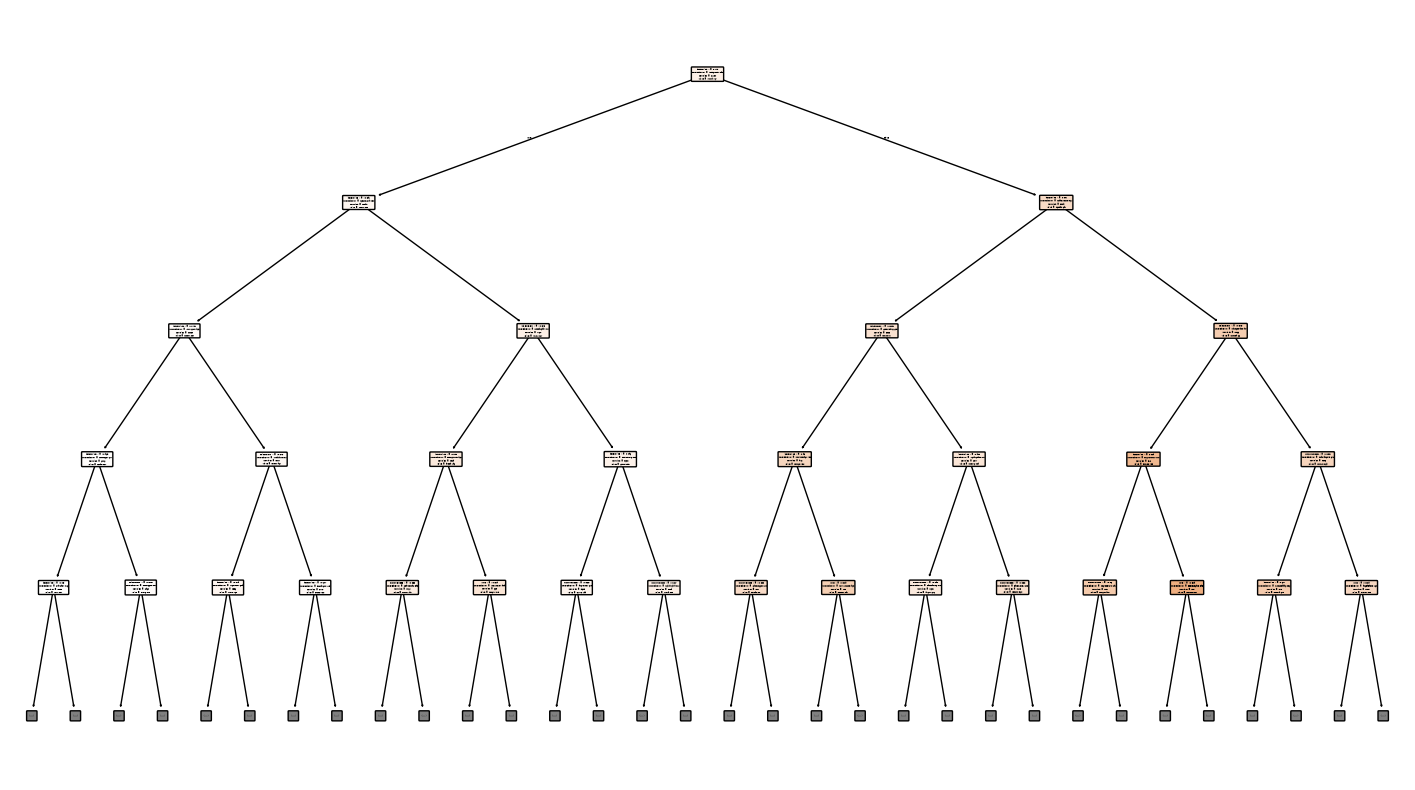

In [24]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_reg,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=4
)
plt.show()

In [25]:
joblib.dump(dt_reg, "decision_tree_regressor.pkl")
print("Decision Tree Regressor saved!")

loaded_dt_reg = joblib.load("decision_tree_regressor.pkl")

def predict_revenue_dt(features_list):
    scaled = scaler.transform(features_list)
    pred = loaded_dt_reg.predict(scaled)[0]
    return float(pred)

# Let's test it with the first row from your dataset as a validation check
test = pd.DataFrame([[1, 3, 1, 2, 0, 28, 1810.89, 65.00, 1, 2, 0, 2023, 11]], columns=X.columns.tolist())
print("Test Input:\n", test)
print("\nPredicted Revenue:", predict_revenue_dt(test))

Decision Tree Regressor saved!
Test Input:
    state  zone  category  brand_type  customer_gender  customer_age  \
0      1     3         1           2                0            28   

   base_price  discount_percent  sales_event  competition_intensity  \
0     1810.89              65.0            1                      2   

   inventory_pressure  order_year  order_month  
0                   0        2023           11  

Predicted Revenue: 25727.377738095245


In [26]:
# RANDOM FOREST REGRESSOR
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    oob_score=True,
    min_samples_split=3,
    min_samples_leaf=1,
    bootstrap=True,
    max_features="sqrt",
    random_state=42
)

rf_reg.fit(X_train_scaled, y_train)

print("OOB Score (R²) (100 estimators) (None as max_Depth):", rf_reg.oob_score_)

OOB Score (R²) (100 estimators) (None as max_Depth): 0.6561965122423095


In [27]:
rf_pred = rf_reg.predict(X_test_scaled)

print("Random Forest Regression Performance:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² score:", r2_score(y_test, rf_pred))

Random Forest Regression Performance:
MAE: 30742.713877459122
MSE: 2452949806.466588
RMSE: 49527.26326445454
R² score: 0.644667190242469


In [28]:
imp = rf_reg.feature_importances_
for name, score in zip(X.columns.tolist(), imp):
    print(f"{name}: {score:.4f}")

joblib.dump(rf_reg, "random_forest_regressor.pkl")
print("\nRandom Forest Regressor saved!")

loaded_rf_reg = joblib.load("random_forest_regressor.pkl")

def predict_revenue_rf(features_list):
    scaled = scaler.transform(features_list)
    pred = loaded_rf_reg.predict(scaled)[0]
    return float(pred)

test_rf = pd.DataFrame([[1, 3, 1, 2, 0, 28, 1810.89, 65.00, 1, 2, 0, 2023, 11]], columns=X.columns.tolist())
print("\nPredicted Revenue (RF):", predict_revenue_rf(test_rf))

state: 0.0405
zone: 0.0316
category: 0.1043
brand_type: 0.0089
customer_gender: 0.0113
customer_age: 0.0711
base_price: 0.5252
discount_percent: 0.0662
sales_event: 0.0548
competition_intensity: 0.0173
inventory_pressure: 0.0098
order_year: 0.0183
order_month: 0.0406

Random Forest Regressor saved!

Predicted Revenue (RF): 42681.70424833332


In [29]:
import joblib

# Save the fitted scaler object to disk
joblib.dump(scaler, "scaler.pkl")
print("Scaler object successfully saved as scaler.pkl!")

Scaler object successfully saved as scaler.pkl!


In [31]:
import xgboost as xgb
import joblib

# Initialize the XGBoost Regressor
# We apply a monotonic constraint of '1' (increasing) to the discount_percent feature.
# Replace '7' with the actual index of 'discount_percent' in your X_train DataFrame.
# Use 0 for features that shouldn't be constrained.
constraints = (0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0) 

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    monotone_constraints=constraints, 
    random_state=42
)

# Train the model on your existing scaled training data
print("Training constrained XGBoost Regressor...")
xgb_model.fit(X_train_scaled, y_train)

# Save the artifact for the FastAPI backend
joblib.dump(xgb_model, 'xgboost_regressor.pkl')
print("✅ xgboost_regressor.pkl saved successfully.")

Training constrained XGBoost Regressor...
✅ xgboost_regressor.pkl saved successfully.


In [33]:
import joblib
from sklearn.metrics import r2_score

# 1. Load the models exactly as they exist on your hard drive
rf_model = joblib.load("random_forest_regressor.pkl")
xgb_model = joblib.load("xgboost_regressor.pkl")

# 2. Calculate Random Forest Metrics
rf_train_preds = rf_model.predict(X_train_scaled)
rf_test_preds = rf_model.predict(X_test_scaled)

rf_train_r2 = r2_score(y_train, rf_train_preds)
rf_test_r2 = r2_score(y_test, rf_test_preds)

print(f"Random Forest -> Train R²: {rf_train_r2:.3f} | Test R²: {rf_test_r2:.3f}")

# 3. Calculate XGBoost Metrics
xgb_train_preds = xgb_model.predict(X_train_scaled)
xgb_test_preds = xgb_model.predict(X_test_scaled)

xgb_train_r2 = r2_score(y_train, xgb_train_preds)
xgb_test_r2 = r2_score(y_test, xgb_test_preds)

print(f"XGBoost (Monotonic) -> Train R²: {xgb_train_r2:.3f} | Test R²: {xgb_test_r2:.3f}")

Random Forest -> Train R²: 0.937 | Test R²: 0.645
XGBoost (Monotonic) -> Train R²: 0.777 | Test R²: 0.637


In [35]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

print("🚀 Initializing Elite Hyperparameter Tuning...\n")

# ==========================================
# 1. TUNE RANDOM FOREST (Fixing Overfitting)
# ==========================================
print("Tuning Random Forest...")

# We restrict depth and force minimum samples in leaves to stop it from memorizing noise
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, 15], 
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=rf_param_grid, 
    n_iter=20, # Tests 20 random combinations
    cv=3,      # 3-fold cross-validation
    verbose=0, 
    random_state=42, 
    n_jobs=-1, # Uses all your CPU cores
    scoring='r2'
)

rf_random.fit(X_train_scaled, y_train)
best_rf = rf_random.best_estimator_

# ==========================================
# 2. TUNE XGBOOST (Maximizing Predictive Power)
# ==========================================
print("Tuning XGBoost (Monotonic)...")

xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1], # Lower learning rate usually yields better generalization
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],       # Randomly samples rows to prevent overfitting
    'colsample_bytree': [0.6, 0.8, 1.0] # Randomly samples columns
}

# Find the index of your discount feature to apply the monotonic constraint
# (Assuming your discount feature is named something like 'Discount_Percent')
# If you used a different name or index in your original training script, update the index here.
discount_feature_index = list(X_train.columns).index('discount_percent') 

# Initialize monotonic constraints (0 for no constraint, -1 for decreasing)
monotone_constraints = tuple([-1 if i == discount_feature_index else 0 for i in range(X_train.shape[1])])

xgb_base = XGBRegressor(
    random_state=42, 
    monotone_constraints=monotone_constraints
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=xgb_param_grid, 
    n_iter=20, 
    cv=3, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1,
    scoring='r2'
)

xgb_random.fit(X_train_scaled, y_train)
best_xgb = xgb_random.best_estimator_

# ==========================================
# 3. EVALUATE & SAVE THE MASTER MODELS
# ==========================================
print("\n✅ TUNING COMPLETE. NEW METRICS:\n")

# Evaluate Tuned RF
rf_train_preds = best_rf.predict(X_train_scaled)
rf_test_preds = best_rf.predict(X_test_scaled)
print(f"Tuned Random Forest -> Train R²: {r2_score(y_train, rf_train_preds):.3f} | Test R²: {r2_score(y_test, rf_test_preds):.3f}")

# Evaluate Tuned XGBoost
xgb_train_preds = best_xgb.predict(X_train_scaled)
xgb_test_preds = best_xgb.predict(X_test_scaled)
print(f"Tuned XGBoost       -> Train R²: {r2_score(y_train, xgb_train_preds):.3f} | Test R²: {r2_score(y_test, xgb_test_preds):.3f}")

# Overwrite the old models with the new elite versions
joblib.dump(best_rf, "random_forest_regressor.pkl")
joblib.dump(best_xgb, "xgboost_regressor.pkl")

print("\n💾 New models saved to disk. Uvicorn will automatically use these on the next API call.")

🚀 Initializing Elite Hyperparameter Tuning...

Tuning Random Forest...
Tuning XGBoost (Monotonic)...

✅ TUNING COMPLETE. NEW METRICS:

Tuned Random Forest -> Train R²: 0.735 | Test R²: 0.650
Tuned XGBoost       -> Train R²: 0.689 | Test R²: 0.660

💾 New models saved to disk. Uvicorn will automatically use these on the next API call.
